In [1]:
import pandas as pd
import json
import numpy as np
import os
import torch
from PIL import Image
from mmengine.config import Config
from transformers import set_seed
import random
import cv2
import h5py
import logging
from logging import Logger
from tqdm import tqdm
from datetime import datetime
from sklearn.metrics import precision_recall_curve, roc_auc_score, accuracy_score

/home/firdavs/miniconda3/envs/firdavs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LOGGING_PATH = f'/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/logging/evaluate_vis_embs-dt=({datetime.now().strftime("%Y-%m-%d-%H-%M")}).log'
EMBEDDINGS_DIR = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/embeddings/vision/'
OUTPUT_DIR = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/evals/cluster_iat/'

# ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generxation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all_mapped.csv'
# ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all-rafal_cluster_mappings.csv'
ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all-o3_cluster_mappings.csv'

def set_seed_all(seed, logger: Logger = None):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    set_seed(seed)
    print(f"Set seed: {seed}")
    if logger:
        logger.info(f"Set seed: {seed}")

set_seed_all(SEED)

Set seed: 42


In [3]:
def load_tmp_df():
    dir_ = '/home/firdavs/surgery/rafal_experiments/fbk_cuts_with_instruments'
    tmp_dfs = []
    for file in os.listdir(dir_):
        path = os.path.join(dir_, file)
        if not path.endswith('.csv'): continue
        tmp_df = pd.read_csv(path)
        tmp_dfs.append(tmp_df)
    tmp_df = pd.concat(tmp_dfs)
    tmp_df = tmp_df.drop(columns=['Unnamed: 0'])
    tmp_df.sort_values(by=['Case', 'Timestamp'], inplace=True)
    tmp_df.reset_index(drop=True, inplace=True)
    return tmp_df
tmp_df = load_tmp_df()

In [4]:
def load_annotations_df(iat_cols = ['instrument-cluster', 'action-cluster', 'tissue-cluster']):
    annotations_df = pd.read_csv(ALL_ANNOTATIONS_PATH)
    fbk_cols = [col for col in annotations_df.columns if col.startswith('f_')]
    annotations_df = annotations_df[['Dialogue', 'Timestamp', 'Case'] + iat_cols + fbk_cols]
    annotations_df['Timestamp'] = annotations_df['Timestamp'].apply(lambda x: f"{int(x.split(':')[0]):02d}:{int(x.split(':')[1]):02d}:{int(x.split(':')[2]):02d}")
    annotations_df.sort_values(by=['Case', 'Timestamp'], inplace=True)
    annotations_df.reset_index(drop=True, inplace=True)
    return annotations_df

all_annotations_df = load_annotations_df()
all_annotations_df['cvid'] = tmp_df['cvid']

In [5]:
all_annotations_df[all_annotations_df['cvid'] == 'c1_s0_2-20-5.avi']

,Dialogue,Timestamp,Case,instrument-cluster,action-cluster,tissue-cluster,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid
327,"more retraction, please... on the prostate sid...",10:57:30,1,retractor,apply_traction,prostate_tissue,0,0,1,0,1,0,0.0,c1_s0_2-20-5.avi


In [6]:
def load_procedures_df():
    procedures_df = pd.read_parquet('../data/urology-related/procedures.parquet')
    return procedures_df

def load_teaching_steps_df():
    teaching_steps_df = pd.read_parquet('../data/urology-related/teaching_steps.parquet')
    teaching_steps_df = teaching_steps_df.sort_values(by=['case_id', 'end_secs'])
    teaching_steps_df.reset_index(drop=True, inplace=True)
    for i in range(len(teaching_steps_df)):
        if i == 0:
            continue
        if teaching_steps_df.loc[i, 'case_id'] == teaching_steps_df.loc[i-1, 'case_id']:
            teaching_steps_df.loc[i, 'start_secs'] = teaching_steps_df.loc[i-1, 'end_secs']
    return teaching_steps_df

procedures_df = load_procedures_df()
teaching_steps_df = load_teaching_steps_df()

teaching_steps_df['duration'] = teaching_steps_df['end_secs'] - teaching_steps_df['start_secs']
print(f"teaching_steps_df['duration'].mean(): {teaching_steps_df['duration'].mean()}")

teaching_step_case_count = []
for case_id in teaching_steps_df['case_id'].unique():
    case_df = teaching_steps_df[teaching_steps_df['case_id'] == case_id]
    teaching_step_case_count.append(len(case_df))
print(f"mean(teaching_step_case_count): {np.mean(teaching_step_case_count)}")

teaching_steps_df['duration'].mean(): 546.4744376278119
mean(teaching_step_case_count): 15.28125


In [7]:
def add_vis_embs(name, annotations_df, force=False):
    annotations_df = annotations_df.copy()
    col_name = f'{name}_vis_embs'
    if col_name not in annotations_df.columns or force:
        embs_path = os.path.join(EMBEDDINGS_DIR, f"{name}_fbk_vis_embs.h5")
        embs_h5 = h5py.File(embs_path, 'r')
        annotations_df[col_name] = annotations_df['cvid'].apply(lambda x: embs_h5[x][:] if x in embs_h5 else None)
        embs_h5.close()
    return annotations_df

# all_annotations_df = add_vis_embs('surgvlp', all_annotations_df)
# all_annotations_df = add_vis_embs('hecvl', all_annotations_df)
all_annotations_df = add_vis_embs('peskavlp', all_annotations_df)
# all_annotations_df = add_vis_embs('videomae_urology', all_annotations_df)
# all_annotations_df = add_vis_embs('videomae_cholect45', all_annotations_df)
# all_annotations_df = add_vis_embs('pe224', all_annotations_df)
# all_annotations_df = add_vis_embs('pe336', all_annotations_df)
# all_annotations_df = add_vis_embs('pe448', all_annotations_df)

In [8]:
vis_emb_cols = [col for col in all_annotations_df.columns if col.endswith('_vis_embs')]
for col in vis_emb_cols:
    print(f"{col}: {all_annotations_df.iloc[0][col].shape if isinstance(all_annotations_df.iloc[0][col], np.ndarray) else 'None'}")

peskavlp_vis_embs: (50, 768)


In [9]:
instrument_remapping_path = '../data/urology-related/o3_instrument_clusters-remapped.json'
action_remapping_path = '../data/urology-related/o3_action_clusters-remapped.json'
tissue_remapping_path = '../data/urology-related/o3_tissue_clusters-remapped.json'

with open(instrument_remapping_path, 'r') as f:
    instrument_remapping = json.load(f)
with open(action_remapping_path, 'r') as f:
    action_remapping = json.load(f)
with open(tissue_remapping_path, 'r') as f:
    tissue_remapping = json.load(f)
    
all_annotations_df['instrument-cluster_remapped'] = all_annotations_df['instrument-cluster'].replace(instrument_remapping)
all_annotations_df['action-cluster_remapped'] = all_annotations_df['action-cluster'].replace(action_remapping)
all_annotations_df['tissue-cluster_remapped'] = all_annotations_df['tissue-cluster'].replace(tissue_remapping)

In [10]:
annotations_df = all_annotations_df.copy()

In [11]:
LABEL_FILTER = 20
INCLUDE_NONE_LABEL = 100
NUM_FOLDS = 5

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
import numpy as np
from imblearn.over_sampling import SMOTE

def evaluate_video_clf(processed_df, metric_avg='weighted', sampler=None, num_folds=NUM_FOLDS, hidden_layer_sizes=(128, 64)):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    auprc_scores = []
    auroc_scores = []
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    confusion_matrices = []

    # pred_rows = []

    # Unique labels
    embeddings = np.array(processed_df['embedding_avg'].values.tolist())
    labels  = np.array(processed_df['label'].values.tolist())
    pred_df = processed_df.copy()
    unique_labels = list(set(labels))
    fold_num = 1
    for train_index, test_index in skf.split(embeddings, labels):
        print(f"Fold {fold_num}/{num_folds}")
        fold_num += 1
        X_train, X_test = embeddings[train_index], embeddings[test_index]
        y_train, y_test = labels[train_index], labels[test_index]
        
        if sampler is not None:
            X_train, y_train = sampler.fit_resample(X_train, y_train)
        
        # Initialize and train a 2-layer MLP with ReLU activation
        model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        
        # Predict the test set
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)
        
        # for i, idx in enumerate(test_index):
        #     pred_rows.append({
        #         'test_index':  idx,
        #         'pred': y_pred[i],
        #         'pred_prob': y_pred_prob[i],
        #         'true': y_test[i],
        #     })
        pred_df.loc[test_index, 'pred'] = y_pred
        
        # Evaluate metrics
        auprc_scores.append(average_precision_score(y_test, y_pred_prob, average=metric_avg))
        auroc_scores.append(roc_auc_score(y_test, y_pred_prob, multi_class='ovo', average=metric_avg if metric_avg is not None else 'weighted'))
        accuracy_scores.append(accuracy_score(y_test, y_pred, normalize=True))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0, average=metric_avg))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0, average=metric_avg))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0, average=metric_avg))
        confusion_matrices.append(confusion_matrix(y_test, y_pred, labels=unique_labels))
    
    mean_auprc = np.mean(auprc_scores)
    mean_auroc = np.mean(auroc_scores)
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    mean_f1 = np.mean(f1_scores)
    
    # pred_df = pd.DataFrame(pred_rows)
    # pred_df['correct'] = pred_df['pred'] == pred_df['true']
    # pred_df = pred_df.sort_values(by=['test_index'])

    return {
        'auprc_scores': auprc_scores,
        'auroc_scores': auroc_scores,
        'accuracy_scores': accuracy_scores,
        'precision_scores': precision_scores,
        'recall_scores': recall_scores,
        'f1_scores': f1_scores,
        'auprc_mean': mean_auprc,
        'auroc_mean': mean_auroc,
        'accuracy_mean': mean_accuracy,
        'precision_mean': mean_precision,
        'recall_mean': mean_recall,
        'f1_mean': mean_f1,
        'confusion_matrix': np.sum(confusion_matrices, axis=0),
        'confusion_matrix_labels': unique_labels,
    }, pred_df
    
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

def evaluate_frame_clf(processed_df, metric_avg='weighted', sampler=None, num_folds=NUM_FOLDS, hidden_layer_sizes=(128, 64), non_class_label=0):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Use video-level splitting (indexing by full video/sample)
    video_embeddings = np.array(processed_df['embedding'].values.tolist())  # [n, num_frames, emb_dim]
    video_labels = np.array(processed_df['label'].values.tolist())          # [n]
    pred_df = processed_df.copy()
    unique_labels = list(set(video_labels))

    auprc_scores, auroc_scores = [], []
    accuracy_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
    confusion_matrices = []

    fold_num = 1
    for train_idx, test_idx in skf.split(video_embeddings, video_labels):
        print(f"Fold {fold_num}/{num_folds}")
        fold_num += 1

        # Train and test sets at the video level
        train_embeddings = video_embeddings[train_idx]  # [n_train, num_frames, dim]
        test_embeddings = video_embeddings[test_idx]
        train_labels = video_labels[train_idx]
        test_labels = video_labels[test_idx]

        # Flatten frame-level embeddings and labels for training
        X_train = np.concatenate(train_embeddings, axis=0)  # [n_train * num_frames, dim]
        y_train = np.concatenate([[lbl]*len(vid) for lbl, vid in zip(train_labels, train_embeddings)])

        if sampler is not None:
            X_train, y_train = sampler.fit_resample(X_train, y_train)

        model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        # Inference: predict all frames in test set
        y_true_all, y_pred_all = [], []
        y_pred_probs_all = []

        video_preds = []
        for i, video in enumerate(test_embeddings):
            video_idx = test_idx[i]
            video_label = test_labels[i]

            frame_preds = model.predict(video)
            frame_probs = model.predict_proba(video)

            # Majority vote
            valid_preds = [p for p in frame_preds] # if p != non_class_label
            if valid_preds:
                maj_vote = Counter(valid_preds).most_common(1)[0][0]
            else:
                maj_vote = non_class_label  # fallback to default

            video_preds.append(maj_vote)
            y_true_all.append(video_label)

            # For metrics like AUROC that need probabilities
            avg_prob = frame_probs.mean(axis=0)
            y_pred_probs_all.append(avg_prob)

        # Save predictions
        pred_df.loc[test_idx, 'pred'] = video_preds

        # Evaluate
        y_pred_all = np.array(video_preds)
        y_pred_probs_all = np.array(y_pred_probs_all)
        y_true_all = np.array(y_true_all)

        auprc_scores.append(average_precision_score(y_true_all, y_pred_probs_all, average=metric_avg))
        auroc_scores.append(roc_auc_score(y_true_all, y_pred_probs_all, multi_class='ovo', average=metric_avg))
        accuracy_scores.append(accuracy_score(y_true_all, y_pred_all))
        precision_scores.append(precision_score(y_true_all, y_pred_all, average=metric_avg, zero_division=0))
        recall_scores.append(recall_score(y_true_all, y_pred_all, average=metric_avg, zero_division=0))
        f1_scores.append(f1_score(y_true_all, y_pred_all, average=metric_avg, zero_division=0))
        confusion_matrices.append(confusion_matrix(y_true_all, y_pred_all, labels=unique_labels))

    return {
        'auprc_scores': auprc_scores,
        'auroc_scores': auroc_scores,
        'accuracy_scores': accuracy_scores,
        'precision_scores': precision_scores,
        'recall_scores': recall_scores,
        'f1_scores': f1_scores,
        'auprc_mean': np.mean(auprc_scores),
        'auroc_mean': np.mean(auroc_scores),
        'accuracy_mean': np.mean(accuracy_scores),
        'precision_mean': np.mean(precision_scores),
        'recall_mean': np.mean(recall_scores),
        'f1_mean': np.mean(f1_scores),
        'confusion_matrix': np.sum(confusion_matrices, axis=0),
        'confusion_matrix_labels': unique_labels,
    }, pred_df


In [15]:
def get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name, label_filter:int = LABEL_FILTER, include_none_label=INCLUDE_NONE_LABEL):
    df = annotations_df.dropna(subset=[f'{model_name}_vis_embs']).copy()
    
    if include_none_label == 'all':
        df[col] = df[col].replace(np.nan, 'None')
    elif isinstance(include_none_label, int) and include_none_label > 0:
        # all df[col] that are np.nan sample include_none_label amount
        df_none = df[df[col].isna()]
        df_none = df_none.sample(n=include_none_label, random_state=SEED)
        df_none[col] = 'None'
        df = pd.concat([df, df_none])
        
    if label_filter is not None:    # Remove labels with less than label_filter counts
        df = df[df[col].map(df[col].value_counts()) >= label_filter]
    
    # Vision embeddings
    vis_embs_avg = np.array(df[f'{model_name}_vis_embs'].values.tolist()).mean(axis=1)
    vis_embs = np.array(df[f'{model_name}_vis_embs'].values.tolist())
    
    emb_col = ''
    if model_name == 'surgvlp': emb_col = 'SurgVLP'
    elif model_name == 'hecvl': emb_col = 'HecVL'
    elif model_name == 'peskavlp': emb_col = 'PeskaVLP'
    elif model_name == 'pe224' or model_name == 'pe336' or model_name == 'pe448': emb_col = 'MedEmbed_small'
    elif model_name == 'videomae_urology' or model_name == 'videomae_cholect45': emb_col = 'MedEmbed_small'
    else:
        raise ValueError(f"Model name {model_name} is not supported.")
    print(f"Embedding column: {emb_col}")
    
    # Procedure embeddings
    procedure_embs = []
    for i in range(len(df)):
        case = df.iloc[i]['Case']
        tmp_df = procedures_df[procedures_df['case_id'] == case]
        procedure_embs.append(tmp_df[f"procedure_defn_emb-{emb_col}"].values[0])
    procedure_embs = np.array(procedure_embs)
    
    # Teaching step embeddings
    teaching_step_embs = []
    df['secs'] = df['cvid'].apply(lambda x: sum([a*b for a,b in zip(map(int, x.split('_')[-1][:-4].split('-')), [3600, 60, 1])]))
    for i in range(len(df)):
        secs = df.iloc[i]['secs']
        case = df.iloc[i]['Case']
        tmp_df = teaching_steps_df[teaching_steps_df['case_id'] == case]
        tmp_df = tmp_df[(tmp_df['start_secs'] <= secs) & (tmp_df['end_secs'] > secs)]
        emb_size = len(teaching_steps_df[f"teaching_step_defn_emb-{emb_col}"].iloc[0])
        if len(tmp_df) == 0:
            # print(f"No teaching step found for case {case} and timestamp {secs}")
            teaching_step_embs.append(np.zeros(emb_size))
        elif len(tmp_df) > 1:
            print(f"Multiple teaching steps found for case {case} and timestamp {secs}")
            teaching_step_embs.append(np.zeros(emb_size))
        else:
            teaching_step_embs.append(tmp_df[f"teaching_step_defn_emb-{emb_col}"].values[0])
    teaching_step_embs = np.array(teaching_step_embs)
    
    # Labels
    labels = np.array(df[col].values.tolist())
    
    df['vis_embs_avg'] = list(vis_embs_avg)
    df['vis_embs'] = list(vis_embs)
    df['procedure_embs'] = list(procedure_embs)
    df['teaching_step_embs'] = list(teaching_step_embs)
    df['label'] = list(labels)
    df = df.reset_index(drop=True)
    
    # n: num samples, num frames: ~50, emb size: 768
    vis_embs = np.array(df['vis_embs'].values.tolist())     # [n, num frames, emb size]
    vis_embs_avg = np.array(df['vis_embs_avg'].values.tolist())     # [n, emb size]
    procedure_embs = np.array(df['procedure_embs'].values.tolist())   # [n, emb size]
    teaching_step_embs = np.array(df['teaching_step_embs'].values.tolist())
    print(f"vis_embs shape: {vis_embs.shape}, procedure_embs shape: {procedure_embs.shape}, teaching_step_embs shape: {teaching_step_embs.shape}")
    
    # make embedding combo by doing [n, num frames, emb size * 3]
    n, num_frames, emb_size = vis_embs.shape
    
    # Repeat procedure and teaching step embeddings along num_frames dimension
    procedure_embs_expanded = np.repeat(procedure_embs[:, np.newaxis, :], num_frames, axis=1)  # [n, num_frames, emb_size]
    teaching_step_embs_expanded = np.repeat(teaching_step_embs[:, np.newaxis, :], num_frames, axis=1)  # [n, num_frames, emb_size]
    
    # Concatenate along the last dimension
    embedding_combo = np.concatenate([vis_embs, procedure_embs_expanded, teaching_step_embs_expanded], axis=2)  # [n, num_frames, emb_size * 3]
    
    df['embedding'] = list(embedding_combo)
    
    # embedding_combo = np.concatenate([vis_embs, procedure_embs, teaching_step_embs], axis=1)
    embedding_comb_avg = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
    # df['embedding'] = list(embedding_combo)
    df['embedding_avg'] = list(embedding_comb_avg)
    
    
    return df

In [16]:
task = 'instrument'
col = 'instrument-cluster_remapped'
model_name = 'peskavlp'
processed_df = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
metrics, pred_df = evaluate_video_clf(processed_df, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Embedding column: PeskaVLP
vis_embs shape: (582, 50, 768), procedure_embs shape: (582, 768), teaching_step_embs shape: (582, 768)
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Mean AUPRC: 0.3534
Mean AUROC: 0.7021
Mean Accuracy: 0.3368
Mean Precision: 0.3382
Mean Recall: 0.3368
Mean F1: 0.3323


In [24]:
task = 'instrument'
col = 'instrument-cluster_remapped'
model_name = 'peskavlp'
processed_df = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
metrics, pred_df = evaluate_frame_clf(processed_df, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Embedding column: PeskaVLP
vis_embs shape: (582, 50, 768), procedure_embs shape: (582, 768), teaching_step_embs shape: (582, 768)
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Mean AUPRC: 0.3452
Mean AUROC: 0.7020
Mean Accuracy: 0.3402
Mean Precision: 0.3439
Mean Recall: 0.3402
Mean F1: 0.3380


In [25]:
vl_both_results_rows = []
# models = ['pe224'] + ['surgvlp', 'hecvl', 'peskavlp'] + ['videomae_urology', 'videomae_cholect45']
# models = ['videomae_urology', 'videomae_cholect45']
# models = ['pe336']
models = ['peskavlp']
pred_dfs_both = {}
for model_name in models:
    for task in ['instrument', 'action', 'tissue']:
        col = f'{task}-cluster_remapped'
        print(f"Model: {model_name}, Task: {task}")
        processed_df = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
        metrics, pred_df = evaluate_frame_clf(processed_df, metric_avg='weighted', hidden_layer_sizes=(256, 64))
        # sample_predictions = get_sample_predictions(final_model, sample_df, col, model_name, 'vision+proc+step')
        vl_both_results_rows.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
            # 'sample_predictions': sample_predictions
        })
        pred_dfs_both[f"{model_name}--{col}"] = pred_df
vl_both_results_df = pd.DataFrame(vl_both_results_rows)

Model: peskavlp, Task: instrument
Embedding column: PeskaVLP
vis_embs shape: (582, 50, 768), procedure_embs shape: (582, 768), teaching_step_embs shape: (582, 768)
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Model: peskavlp, Task: action
Embedding column: PeskaVLP
vis_embs shape: (1088, 50, 768), procedure_embs shape: (1088, 768), teaching_step_embs shape: (1088, 768)
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Model: peskavlp, Task: tissue
Embedding column: PeskaVLP
vis_embs shape: (782, 50, 768), procedure_embs shape: (782, 768), teaching_step_embs shape: (782, 768)
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


In [14]:
vl_both_results_frame_path = os.path.join(OUTPUT_DIR, f'vl_both_results_frame-o3_clusters_remapped-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')
# vl_both_results_df.to_csv(vl_both_results_frame_path, index=False)

In [ ]:
import pickle
with open(os.path.join(
    OUTPUT_DIR,
    f'vL_both_pred_dfs_frame-PeskaVLP-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.pkl'
), 'wb') as f:
    pickle.dump(pred_dfs_both, f)

In [17]:
def convert_np_arr_str_to_arr(arr_str: str) -> np.ndarray:
    import re
    # grab everything that sits between a pair of brackets: [...numbers...]
    row_chunks = re.findall(r'\[([^\[\]]+)\]', arr_str)
    rows = [list(map(int, chunk.split())) for chunk in row_chunks]
    return np.array(rows)

from ast import literal_eval


# def convert_np_arr_str_to_arr(arr_str: str) -> np.ndarray:
#     return np.array(ast.literal_eval(arr_str))

def plot_confusion_matrices(confusion_matrices_df, suptitle, models: list, figsize_multiplier=4):
    import matplotlib.pyplot as plt
    import numpy as np

    tasks_order  = ['instrument', 'action', 'tissue']

    # df_plot = vision_confusion_matrices_df.set_index(['model', 'task'])
    df_plot = confusion_matrices_df.set_index(['model', 'task'])
    

    # --- 3 rows (tasks) × 5 columns (models) -----------------
    n_rows, n_cols = len(tasks_order), len(models)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_multiplier * n_cols, figsize_multiplier * n_rows))
    axes = axes.reshape((len(tasks_order), len(models)))
    # fig.suptitle("Vision-only Confusion Matrices", fontsize=14)
    fig.suptitle(suptitle, fontsize=14)

    ax_count = 0
    for i, task in enumerate(tasks_order):               # rows = tasks (top → bottom)
        for j, model in enumerate(models):               # cols = models (left → right)
            ax = axes[i, j]
            # ax = axes[ax_count]
            # ax_count += 1
            row = df_plot.loc[(model, task)]
            try:
                if isinstance(row['confusion_matrix'], str):
                    cm = convert_np_arr_str_to_arr(row['confusion_matrix'])
                else:
                    cm = np.array(row['confusion_matrix'])
            except Exception as e:
                print(e)
                continue
            if isinstance(row['confusion_matrix_labels'], str):
                label_str = row['confusion_matrix_labels']

                label_str_cleaned = label_str.replace("np.str_", "")
                import ast
                labels = ast.literal_eval(label_str_cleaned)
            else:
                labels = row['confusion_matrix_labels']
            
            ax.imshow(cm, origin='upper')  # default colormap
            if labels is not None:
                ax.set_yticks(np.arange(len(labels)))
                ax.set_yticklabels(labels, fontsize=6)
                ax.set_xticks(np.arange(len(labels)))
                ax.set_xticklabels(labels, fontsize=6, rotation=90)

            ax.set_title(model, fontsize=9) if i == 0 else None          # titles only on top row
            if j == 0:
                ax.set_ylabel(f'{task}\nTrue')
            ax.set_xlabel('Predicted')

            for (x, y), v in np.ndenumerate(cm):
                ax.text(y, x, int(v), ha='center', va='center', fontsize=7)

    fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for suptitle
    plt.show()

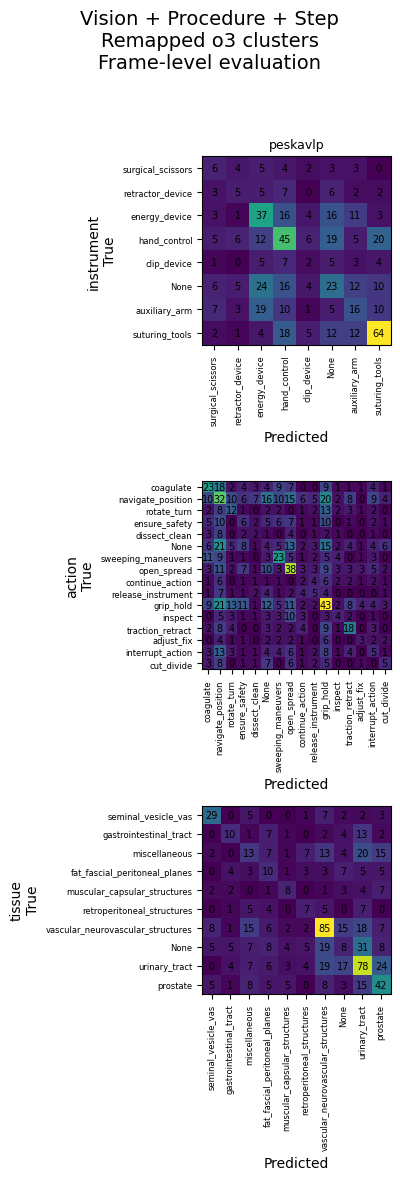

In [18]:
vl_both_results_df_loaded = pd.read_csv(vl_both_results_frame_path)
plot_confusion_matrices(
    pd.read_csv(os.path.join(OUTPUT_DIR, f'vl_both_results_frame-o3_clusters_remapped-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')), 
    'Vision + Procedure + Step\nRemapped o3 clusters\nFrame-level evaluation',
    models=['peskavlp'],
)

In [19]:
vl_both_results_df_loaded

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,peskavlp,instrument,0.345160,0.701983,0.340230,0.343891,0.340230,0.338022,[[ 6 4 5 4 2 3 3 0]\n [ 3 5 5 7 0 ...,"[np.str_('surgical_scissors'), np.str_('retrac..."
1,peskavlp,action,0.200831,0.626495,0.206819,0.199677,0.206819,0.200361,[[23 18 2 4 3 4 9 7 0 0 9 1 1 1 4...,"[np.str_('coagulate'), np.str_('navigate_posit..."
2,peskavlp,tissue,0.362726,0.729294,0.370880,0.353827,0.370880,0.353569,[[29 0 5 0 0 1 7 2 2 3]\n [ 0 10 1 ...,"[np.str_('seminal_vesicle_vas'), np.str_('gast..."


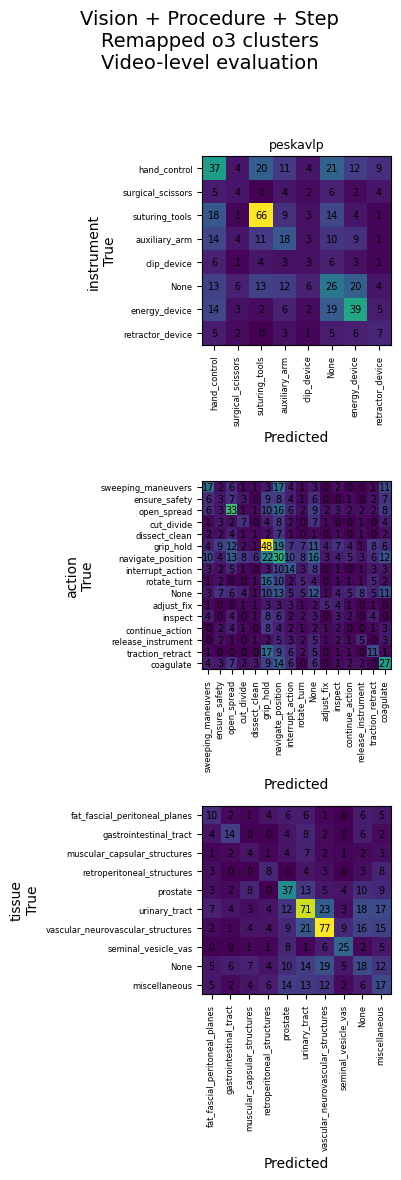

In [20]:
import pandas as pd
plot_confusion_matrices(
    pd.read_csv(os.path.join(OUTPUT_DIR, f'vl_both_results-o3_clusters_remapped-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')), 
    'Vision + Procedure + Step\nRemapped o3 clusters\nVideo-level evaluation',
    models=['peskavlp'],
)

In [16]:
vl_both_results_df_loaded

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,peskavlp,instrument,0.345160,0.701983,0.340230,0.343891,0.340230,0.338022,[[ 6 4 5 4 2 3 3 0]\n [ 3 5 5 7 0 ...,"[np.str_('surgical_scissors'), np.str_('retrac..."
1,peskavlp,action,0.200831,0.626495,0.206819,0.199677,0.206819,0.200361,[[23 18 2 4 3 4 9 7 0 0 9 1 1 1 4...,"[np.str_('coagulate'), np.str_('navigate_posit..."
2,peskavlp,tissue,0.362726,0.729294,0.370880,0.353827,0.370880,0.353569,[[29 0 5 0 0 1 7 2 2 3]\n [ 0 10 1 ...,"[np.str_('seminal_vesicle_vas'), np.str_('gast..."
